In [ ]:
import os
import json
import pandas as pd
import geopandas as gpd
from shapely import wkt
from copy import deepcopy 
import matplotlib.pyplot as plt
import contextily as cx
from typing import Dict, Any
from shapely.geometry import LineString, Point
from random import uniform
import momepy
import networkx as nx
import numpy as np
import warnings
from path_planning_env import PathPlanningEnv
from stable_baselines3 import PPO, A2C, DQN, SAC, TD3


In [5]:
def create_network_graph(G_df):
    # Make bi-directionality of sidewalks (and not of bike paths) explicit
    G_df['oneway'] = np.where(G_df['bikepath_id'].isna(), False, True)

    # Create graphs that take directionality into account
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", category=RuntimeWarning)
        G = momepy.gdf_to_nx(G_df, approach="primal", multigraph=True, directed=True, length="length", oneway_column="oneway")
    
    # Generate nodes position data
    for node in G.nodes:
        G.nodes[node]['pos'] = node

    return G

def load_map_data(map_name: str) -> Dict[str, Any]:
    """
    Load the required map data files.
    """
    # Load network data
    basic_network_path = f'./network_{map_name}'
    df = gpd.read_file(basic_network_path)

    # Load metadata
    meta_data_path = f'./metadata_{map_name}.json'
    with open(meta_data_path, 'r') as f:
        meta_data = json.load(f)

    return {
        "df": df,
        "meta_data": meta_data,
    }

def plot_route_with_network(
    df: gpd.GeoDataFrame,
    df_path_fact: gpd.GeoDataFrame,
    gdf_coords: gpd.GeoDataFrame,
    origin_node_loc: Point,
    dest_node_loc: Point,
    meta_map: Dict[str, Any],
    buffer_radius: float,
    figsize: tuple = (12, 12),
) -> None:
    gdf_coords["buffer"] = gdf_coords["geometry"].buffer(buffer_radius, cap_style=3)
    plot_area = gpd.GeoDataFrame(
        geometry=[gdf_coords["buffer"][0].union(gdf_coords["buffer"][1])],
        crs=meta_map["CRS"],
    )
    df_sub = gpd.sjoin(df, plot_area, how='inner').reset_index()

    fig, ax = plt.subplots(figsize=figsize)
    df_sub.plot(ax=ax, color='lightgrey', linewidth=1, label='Network')
    df_path_fact.plot(ax=ax, color='grey', linewidth=4, label='Route')

    gdf_coords.head(1).plot(ax=ax, color='blue', markersize=50, label='Origin Location')
    gdf_coords.tail(1).plot(ax=ax, color='red', markersize=50, label='Destination Location')

    gpd.GeoSeries([origin_node_loc], crs=meta_map["CRS"]).plot(ax=ax, color='green', markersize=20, label='Origin Node')
    gpd.GeoSeries([dest_node_loc], crs=meta_map["CRS"]).plot(ax=ax, color='yellow', markersize=20, label='Destination Node')

    cx.add_basemap(ax=ax, 
                  source=cx.providers.CartoDB.Voyager,
                  crs=meta_map["CRS"]) 

    plt.legend(loc="lower right")
    plt.axis('off')
    plt.show()

def load_route_from_file(file_path: str, meta_map: dict) -> gpd.GeoDataFrame:
    """
    Load the route (GeoDataFrame) from a file in GeoPackage format.
    """
    loaded_route = gpd.read_file(file_path)
    loaded_route = loaded_route.set_crs(meta_map["CRS"], allow_override=True)
    if loaded_route.empty or loaded_route.geometry.isnull().all():
        raise ValueError(f"Loaded route data is empty or has invalid geometry: {file_path}")  
    print(f"Route loaded from {file_path}")
    return loaded_route


## Load Map Data


In [6]:
map_name = "demo_walk"
data = load_map_data(map_name)
df, meta_data = data["df"], data["meta_data"]
df_copy = deepcopy(df)

def round_node(node, ndigits=5):
    return (round(node[0], ndigits), round(node[1], ndigits))

G = create_network_graph(df_copy)
G = nx.relabel_nodes(G, lambda n: round_node(n))
G.remove_edges_from(nx.selfloop_edges(G))
print(G)  # 打印图的基本信息

print("节点列表：", list(G.nodes))  # 打印所有节点
print("边列表：", list(G.edges))   # 打印所有边

# 打印每个节点的属性
for node, data in G.nodes(data=True):
    print(f"节点: {node}, 属性: {data}")

# 打印每条边的属性
for u, v, data in G.edges(data=True):
    print(f"边: {u} -> {v}, 属性: {data}")

MultiDiGraph with 278 nodes and 800 edges
节点列表： [(114622.88334, 484930.72337), (114618.84638, 484929.45387), (114620.63238, 484927.69017), (114607.86238, 484930.06423), (114631.57347, 484935.65971), (114627.90267, 484937.11078), (114634.48468, 484936.58676), (114627.07615, 484935.6136), (114616.47766, 484934.97829), (114617.46382, 484932.85623), (114610.83986, 484933.17724), (114608.96539, 484932.56491), (114608.51513, 484938.509), (114607.09507, 484931.9431), (114606.62351, 484937.914), (114607.09635, 484934.5829), (114608.54669, 484930.2983), (114605.25487, 484940.1948), (114604.71893, 484937.3696), (114603.88562, 484937.17695), (114622.60216, 484928.76329), (114636.6608, 484939.88726), (114638.89707, 484935.88946), (114637.96428, 484941.38478), (114636.68849, 484938.37096), (114638.94158, 484935.79992), (114646.447, 484938.3833), (114646.30082, 484941.12832), (114651.93998, 484940.01631), (114656.9892, 484941.75779), (114652.82322, 484937.39274), (114675.95932, 484947.71623), (11467

## Initialize Env


In [7]:
data_dir = f'./data/train/'
route_id = 0
# Load corresponding origin/destination CSV file
gdf_coords_path = os.path.join(data_dir, f'route_demo_walk_{route_id}_start_end.csv')
if not os.path.exists(gdf_coords_path):
    print(f"Corresponding CSV file not found for route: {route_id}")

gdf_coords_loaded = pd.read_csv(gdf_coords_path, sep=';')

# Process origin/destination points and nodes
gdf_coords = gdf_coords_loaded[['coordinates', 'geometry']]
gdf_coords['geometry'] = gdf_coords['geometry'].apply(wkt.loads)
gdf_coords = gpd.GeoDataFrame(gdf_coords, geometry='geometry')
origin_node_loc = gdf_coords.loc[gdf_coords['coordinates'] == 'origin_node', 'geometry'].values[0]
dest_node_loc = gdf_coords.loc[gdf_coords['coordinates'] == 'destination_node', 'geometry'].values[0]

# origin_node = (origin_node_loc.x, origin_node_loc.y)
# destination_node = (dest_node_loc.x, dest_node_loc.y)
origin_node = round_node((origin_node_loc.x, origin_node_loc.y))
destination_node = round_node((dest_node_loc.x, dest_node_loc.y))
# Testing finding the shortest path between origin and destination
# try:
#     path = nx.shortest_path(G, origin_node, destination_node, weight='length')
#     print(f"Shortest path length: {nx.path_weight(G, path, 'length'):.2f} m")
# except nx.NetworkXNoPath:
#     print("Error! No path is found")

env = PathPlanningEnv(
    G=G,
    start_node=origin_node,
    end_node=destination_node,
    max_steps=200
)

## Start SAC training

In [8]:
model = PPO(
    "MlpPolicy",
    env,
    # device="cuda",
    verbose=1,
    learning_rate=1e-4,
    batch_size=256,
    gamma=0.99,
    policy_kwargs=dict(net_arch=[256, 256])
)
model.learn(total_timesteps=100_000)

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
----------------------------------
| rollout/           |           |
|    ep_len_mean     | 124       |
|    ep_rew_mean     | -9.67e+03 |
| time/              |           |
|    fps             | 491       |
|    iterations      | 1         |
|    time_elapsed    | 4         |
|    total_timesteps | 2048      |
----------------------------------
------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 108          |
|    ep_rew_mean          | -7.9e+03     |
| time/                   |              |
|    fps                  | 439          |
|    iterations           | 2            |
|    time_elapsed         | 9            |
|    total_timesteps      | 4096         |
| train/                  |              |
|    approx_kl            | 0.0001088267 |
|    clip_fraction        | 0            |
|    clip_range           | 0.2         

In [9]:
obs, info = env.reset()
print(f"Initial observation: {obs} , info: {info}")
print(f"Start node: {env.current_node}, End node: {env.end_node}")

path = []
path.append(env.current_node)

# Simulate the environment for 100 steps
for _ in range(1000):
    action, state = model.predict(obs, deterministic=False)
    obs, reward, done, truncated, info = env.step(action)
    print(f"Current node: {env.current_node}, Action taken: {action}, State: {state}")
    print(f"Observation: {obs}, Reward: {reward}, Done: {done}, Truncated: {truncated}, Info: {info}")

    finished = done or truncated

    path.append(env.current_node)
    if finished:
        break

print(f"Path taken: {path}")

Initial observation: [ 1.14663895e+05  4.85031069e+05  9.08687000e+00 -7.79619600e+01
  0.00000000e+00] , info: {}
Start node: (114663.8951, 485031.06875), End node: (114672.98197, 484953.10679)
Current node: (114667.43999, 485029.27391), Action taken: 0, State: None
Observation: [ 1.14667440e+05  4.85029274e+05  5.54198000e+00 -7.61671200e+01
  5.00000000e-03], Reward: 21.112611642677358, Done: False, Truncated: False, Info: {}
Current node: (114677.38697, 484999.25627), Action taken: 3, State: None
Observation: [ 1.14677387e+05  4.84999256e+05 -4.40500000e+00 -4.61494800e+01
  1.00000000e-02], Reward: 299.99239797417385, Done: False, Truncated: False, Info: {}
Current node: (114677.5703, 484998.6807), Action taken: 1, State: None
Observation: [ 1.14677570e+05  4.84998681e+05 -4.58833000e+00 -4.55739100e+01
  1.50000000e-02], Reward: 5.4493188652521045, Done: False, Truncated: False, Info: {}
Current node: (114677.38697, 484999.25627), Action taken: 1, State: None
Observation: [ 1.146

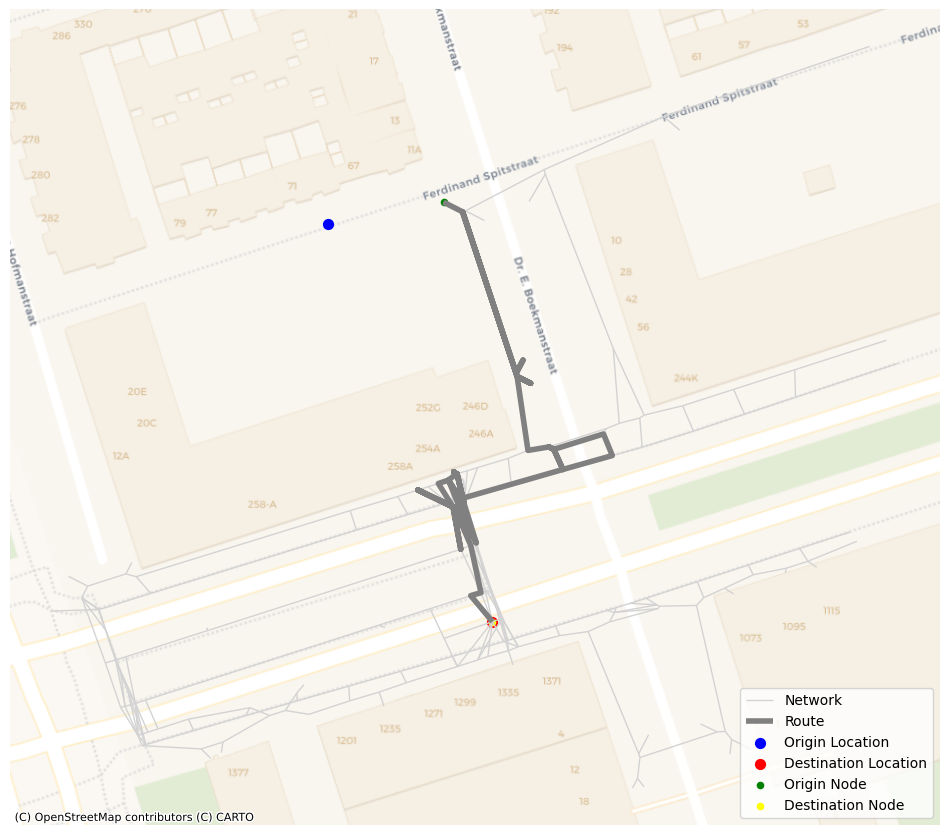

In [10]:
geometry = LineString(path)
df_path_fact = gpd.GeoDataFrame(geometry=[geometry], crs=meta_data["CRS"])
plot_route_with_network(
    df=df,
    df_path_fact=df_path_fact,
    gdf_coords=gdf_coords,
    origin_node_loc=origin_node_loc,
    dest_node_loc=dest_node_loc,
    meta_map=meta_data,
    buffer_radius=70,
)

## Load route file

In [8]:
# # Load corresponding route file
# file_path = f'{data_dir}p_route_demo_walk_{route_id}.gpkg'
# loaded_route = load_route_from_file(file_path, meta_data)
# # Plotting the route for demonstration
# plot_route_with_network(
#     df=df,
#     df_path_fact=loaded_route,
#     gdf_coords=gdf_coords,
#     origin_node_loc=origin_node_loc,
#     dest_node_loc=dest_node_loc,
#     meta_map=meta_data,
#     buffer_radius=70,
# )

In [9]:
# fig, ax = plt.subplots(figsize=(12, 12))
# pos = nx.get_node_attributes(G, 'pos')

# nx.draw(
#     G,
#     pos=pos,
#     nodelist=G.nodes,
#     node_size=10,
#     node_color='blue',
#     alpha=0.5

# )

# plt.plot(
#     origin_node[0], origin_node[1], 
#     'go', markersize=5, label='Origin Node'
# )
# plt.plot(
#     destination_node[0], destination_node[1], 
#     'ro', markersize=5, label='Destination Node'
# )

# loaded_route.plot(ax=ax, color='yellow', linewidth=2, zorder=2)

# if path:
#     path_coords = [pos[node] for node in path]
#     plt.plot(
#         [p[0] for p in path_coords],
#         [p[1] for p in path_coords],
#         color='purple',
#         linewidth=3,
#         label='Shortest Path'
#     )

# plt.title("Demo")
# plt.legend()
# plt.show()

In [10]:
# def save_route_to_file(gdf_route: gpd.GeoDataFrame, store_path: str, route_name: str, route_id: int) -> None:
#     """
#     Save the route (GeoDataFrame) to a file in GeoPackage format.
#     """
#     file_path = f'{store_path}p_route_{route_name}_{route_id}.gpkg'
#     gdf_route.to_file(file_path, driver='GPKG')
#     print(f"Route saved to {file_path}")

# def load_route_from_file(store_path: str, route_name: str, route_id: int, meta_map: dict) -> gpd.GeoDataFrame:
#     """
#     Load the route (GeoDataFrame) from a file in GeoPackage format.
#     """
#     file_path = f'{store_path}p_route_{route_name}_{route_id}.gpkg'
#     loaded_route = gpd.read_file(file_path)
#     loaded_route = loaded_route.set_crs(meta_map["CRS"], allow_override=True)
#     if loaded_route.empty or loaded_route.geometry.isnull().all():
#         raise ValueError(f"Loaded route data is empty or has invalid geometry: {file_path}")  
#     print(f"Route loaded from {file_path}")
#     return loaded_route

# def plot_route_with_network(
#     df: gpd.GeoDataFrame,
#     df_path_fact: gpd.GeoDataFrame,
#     gdf_coords: gpd.GeoDataFrame,
#     origin_node_loc: Point,
#     dest_node_loc: Point,
#     meta_map: Dict[str, Any],
#     buffer_radius: float,
#     figsize: tuple = (12, 12),
# ) -> None:
#     gdf_coords["buffer"] = gdf_coords["geometry"].buffer(buffer_radius, cap_style=3)
#     plot_area = gpd.GeoDataFrame(
#         geometry=[gdf_coords["buffer"][0].union(gdf_coords["buffer"][1])],
#         crs=meta_map["CRS"],
#     )
#     df_sub = gpd.sjoin(df, plot_area, how='inner').reset_index()

#     fig, ax = plt.subplots(figsize=figsize)
#     df_sub.plot(ax=ax, color='lightgrey', linewidth=1, label='Network')
#     df_path_fact.plot(ax=ax, color='grey', linewidth=4, label='Route')

#     gdf_coords.head(1).plot(ax=ax, color='blue', markersize=50, label='Origin Location')
#     gdf_coords.tail(1).plot(ax=ax, color='red', markersize=50, label='Destination Location')

#     gpd.GeoSeries([origin_node_loc], crs=meta_map["CRS"]).plot(ax=ax, color='green', markersize=20, label='Origin Node')
#     gpd.GeoSeries([dest_node_loc], crs=meta_map["CRS"]).plot(ax=ax, color='yellow', markersize=20, label='Destination Node')

#     cx.add_basemap(ax=ax, 
#                   source=cx.providers.CartoDB.Voyager,
#                   crs=meta_map["CRS"]) 

#     plt.legend(loc="lower right")
#     plt.axis('off')
#     plt.show()

# def load_data(map_name: str, map_id: int) -> Dict[str, Any]:
#     """
#     Load the required data files for route generation and plotting.
#     """
#     # Load network data
#     basic_network_path = f'./examples/{map_name}/network_demo_walk_{map_id}'
#     df = gpd.read_file(basic_network_path)

#     # Load metadata
#     meta_data_path = f'./examples/{map_name}/metadata_{map_name}_{map_id}.json'
#     with open(meta_data_path, 'r') as f:
#         meta_data = json.load(f)

#     return {
#         "df": df,
#         "meta_data": meta_data,
#     }

# def generate_route(
#     df: gpd.GeoDataFrame,
#     gdf_coords_loaded: gpd.GeoDataFrame,
#     meta_data: Dict[str, Any],
#     heuristic: str = "dijkstra",
#     heuristic_f: str = "my_weight",
# ) -> Dict[str, Any]:
#     """
#     Generate the route based on the given network data, user preferences and heuristic.
#     """
#     user_model = meta_data["user_model"]
#     meta_map = meta_data["map"]
#     df_copy = deepcopy(df)
#     df_copy = handle_weight(df_copy, user_model)
#     _, G = create_network_graph(df_copy)
#     router_h = Router(heuristic=heuristic, CRS=meta_map["CRS"], CRS_map=meta_map["CRS_map"])
#     origin_node, dest_node, origin_node_loc, dest_node_loc, gdf_coords = router_h.set_o_d_coords(G, gdf_coords_loaded)
#     path_fact, G_path_fact, df_path_fact = router_h.get_route(G, origin_node, dest_node, heuristic_f)
#     return {
#         "path_fact": path_fact,
#         "G_path_fact": G_path_fact,
#         "df_path_fact": df_path_fact,
#         "origin_node_loc": origin_node_loc,
#         "dest_node_loc": dest_node_loc,
#         "gdf_coords": gdf_coords,
#         "meta_map": meta_map,
#     }

# def generate_random_points(df: gpd.GeoDataFrame, crs: str, num_routes: int) -> gpd.GeoDataFrame:
#     """
#     Generate random start and end points for multiple routes within the bounding box of the network.

#     Parameters:
#         df (GeoDataFrame): The GeoDataFrame representing the network.
#         crs (str): The coordinate reference system (CRS) of the network.
#         num_routes (int): Number of routes to generate.

#     Returns:
#         GeoDataFrame: A GeoDataFrame containing pairs of random points for each route.
#     """
#     bounds = df.total_bounds  # [minx, miny, maxx, maxy]
#     minx, miny, maxx, maxy = bounds

#     random_points = [
#         Point(uniform(minx, maxx), uniform(miny, maxy)) for _ in range(2 * num_routes)
#     ]

#     # Create a GeoDataFrame with pairs of random points
#     gdf_random_points = gpd.GeoDataFrame(
#         {'coordinates': ['origin', 'destination'] * num_routes},  # Alternating 'origin' and 'destination'
#         geometry=random_points,
#         crs=crs,
#     )
#     return gdf_random_points
    
# def batch_generate_routes(
#     num_routes: int,
#     df: gpd.GeoDataFrame,
#     meta_data: Dict[str, Any],
#     output_dir: str,
#     route_name: str,
# ) -> None:
#     """
#     Generate multiple routes and save them to files.

#     Parameters:
#         num_routes (int): Number of routes to generate.
#         df (GeoDataFrame): The GeoDataFrame representing the network.
#         meta_data (Dict): Metadata containing map and user model information.
#         output_dir (str): Directory to save the routes.
#         route_name (str): Name prefix for the routes.
#     """
#     crs = meta_data["map"]["CRS"]
#     # Generate random points for all routes
#     gdf_random_points = generate_random_points(df, crs, num_routes)

#     # Ensure output directory exists
#     os.makedirs(output_dir, exist_ok=True)

#     # Generate and save each route
#     for i in range(num_routes):
#         try:
#             # Extract the start and end points for the current route
#             gdf_coords_loaded = gdf_random_points.iloc[2 * i:2 * i + 2]

#             # Generate the route
#             route_data = generate_route(df, gdf_coords_loaded, meta_data)
#             origin_node_loc, dest_node_loc = route_data["origin_node_loc"], route_data["dest_node_loc"]
#             df_path_fact = route_data["df_path_fact"]

#             # Save the route
#             save_route_to_file(df_path_fact, output_dir, route_name, i)
#             csv_file_name = os.path.join(output_dir, f'route_{route_name}_{i}_start_end.csv')
#             gdf_combined = gpd.GeoDataFrame(
#                 {
#                     'coordinates': gdf_coords_loaded['coordinates'].tolist() + ['origin_node', 'destination_node'],
#                     'geometry': gdf_coords_loaded['geometry'].tolist() + [origin_node_loc, dest_node_loc],
#                 },
#                 crs=gdf_coords_loaded.crs
#             )
#             gdf_combined.to_csv(csv_file_name, sep=';', index=False)
#         except Exception as e:
#             print(f"Error generating route {i}: {e}")
#             continue

# def plot_all_routes(route_name: str, output_dir: str, map_name: str, map_id: int) -> None:
#     """
#     Load and plot routes using corresponding CSV files and the same map.

#     Parameters:
#         route_name (str): The name of the route.
#         output_dir (str): The directory where route files are stored.
#         map_name (str): The name of the map used for the routes.
#         map_id (int): The ID of the map used for the routes.
#     """
#     # Load the map data and metadata
#     data = load_data(map_name, map_id)
#     df, meta_data = data["df"], data["meta_data"]
#     meta_map = meta_data["map"]

#     # Get list of route files
#     files = os.listdir(output_dir)
#     route_files = [f for f in files if f.endswith('.gpkg')]

#     if not route_files:
#         print("No valid route files found in the folder.")
#         return
    
#     max_files_to_process = 2

#     processed_count = 0

#     # Iterate over route files and corresponding CSVs
#     for route_file in route_files:
#         if processed_count >= max_files_to_process:
#             print(f"Processed {max_files_to_process} files. Stopping further processing.")
#             break
#         try:
#             # Load route GeoPackage file
#             file_path = os.path.join(output_dir, route_file)

#             # Extract route ID from the file name
#             route_id = int(route_file.split('_')[-1].split('.')[0])

#             route_data = load_route_from_file(output_dir, route_name, route_id, meta_map)

#             # Validate route data
#             if route_data.empty or route_data.geometry.isnull().all():
#                 print(f"Invalid geometry in file: {file_path}")
#                 continue

#             # Load corresponding start/end CSV file
#             gdf_coords_path = os.path.join(output_dir, f'route_{route_name}_{route_id}_start_end.csv')
#             if not os.path.exists(gdf_coords_path):
#                 print(f"Corresponding CSV file not found for route: {route_file}")
#                 continue

#             gdf_coords_loaded = pd.read_csv(gdf_coords_path, sep=';')

#             # Process start/end points and nodes
#             gdf_coords = gdf_coords_loaded[['coordinates', 'geometry']]
#             gdf_coords['geometry'] = gdf_coords['geometry'].apply(wkt.loads)
#             gdf_coords = gpd.GeoDataFrame(gdf_coords, geometry='geometry')

#             gdf_coords_loaded['geometry'] = gdf_coords_loaded['geometry'].apply(wkt.loads)
#             gdf_coords = gpd.GeoDataFrame(gdf_coords_loaded, geometry='geometry')

#             origin_point = gdf_coords.loc[gdf_coords['coordinates'] == 'origin', 'geometry'].values[0]
#             dest_point = gdf_coords.loc[gdf_coords['coordinates'] == 'destination', 'geometry'].values[0]
#             origin_node_loc = gdf_coords.loc[gdf_coords['coordinates'] == 'origin_node', 'geometry'].values[0]
#             dest_node_loc = gdf_coords.loc[gdf_coords['coordinates'] == 'destination_node', 'geometry'].values[0]
#             gdf_coords = gdf_coords[gdf_coords['coordinates'].isin(['origin', 'destination'])]

#             # Plot the route
#             print(f"Plotting route from file: {route_file}")
#             plot_route_with_network(
#                 df=df,
#                 df_path_fact=route_data,
#                 gdf_coords=gdf_coords,
#                 origin_node_loc=origin_node_loc,
#                 dest_node_loc=dest_node_loc,
#                 meta_map=meta_map,
#                 buffer_radius=70,
#             )

#             processed_count += 1

#         except Exception as e:
#             print(f"Error processing route file {route_file}: {e}")
#             # try:
#             #     if os.path.exists(file_path):
#             #         print(f"Deleting invalid route file: {file_path}")
#             #         os.remove(file_path)

#             #     if os.path.exists(gdf_coords_path):
#             #         print(f"Deleting corresponding CSV file: {gdf_coords_path}")
#             #         os.remove(gdf_coords_path)
#             # except Exception as delete_error:
#             #     print(f"Error deleting files: {delete_error}")
#             continue

# def count_routes_and_remove_duplicates(route_name: str, output_dir: str, map_name: str, map_id: int) -> int:
#     """
#     Count routes and remove duplicate files using corresponding GeoPackage files.

#     Parameters:
#         route_name (str): The name of the route.
#         output_dir (str): The directory where route files are stored.
#         map_name (str): The name of the map used for the routes.
#         map_id (int): The ID of the map used for the routes.

#     Returns:
#         int: The number of unique routes after removing duplicates.
#     """
#     # Get list of route files
#     files = os.listdir(output_dir)
#     route_files = [f for f in files if f.endswith('.gpkg')]

#     if not route_files:
#         print("No valid route files found in the folder.")
#         return 0

#     # Initialize a Counter to store route occurrences
#     route_counter = Counter()

#     # Store the mapping of geometry to associated files
#     geometry_to_files = {}

#     # Iterate over route files
#     for route_file in route_files:
#         try:
#             # Load route GeoPackage file
#             file_path = os.path.join(output_dir, route_file)
#             route_data = gpd.read_file(file_path)

#             # Validate route data
#             if route_data.empty or route_data.geometry.isnull().all():
#                 print(f"Invalid geometry in file: {file_path}")
#                 continue

#             # Convert route geometry to a hashable format
#             route_geometry = route_data.geometry.apply(lambda geom: geom.wkt).tolist()
#             route_geometry_tuple = tuple(sorted(route_geometry))  # Sort to ensure consistent ordering

#             # Add to route counter and file mapping
#             route_counter[route_geometry_tuple] += 1

#             geometry_to_files.setdefault(route_geometry_tuple, []).append(route_file)
#         except Exception as e:
#             print(f"Error processing route file {route_file}: {e}")
#             continue

#     # Delete duplicate files
#     for geometry, files in geometry_to_files.items():
#         if len(files) > 1:  # If there are duplicate files

#             for duplicate_file in files[1:]:  # Keep the first file, delete the rest

#                 duplicate_gpkg_path = os.path.join(output_dir, duplicate_file)
#                 duplicate_csv_path = os.path.join(output_dir, f'route_{route_name}_{duplicate_file.split("_")[-1].split(".")[0]}_start_end.csv')

#                 try:
#                     if os.path.exists(duplicate_gpkg_path):
#                         print(f"Deleting duplicate GeoPackage file: {duplicate_gpkg_path}")
#                         os.remove(duplicate_gpkg_path)

#                     if os.path.exists(duplicate_csv_path):
#                         print(f"Deleting corresponding CSV file: {duplicate_csv_path}")
#                         os.remove(duplicate_csv_path)
#                 except Exception as delete_error:
#                     print(f"Error deleting files: {delete_error}")

#     return len(route_counter)

In [11]:
# def main():
#     map_name = "demo_walk"
#     map_id = 0
#     route_name = "demo_walk"

#     num_routes = 50000  # Change this to 1000 or 10000 as needed

#     output_dir = f'./examples/{route_name}/test/'
#     os.makedirs(output_dir, exist_ok=True)

#     # Load data
#     data = load_data(map_name, map_id)
#     df, meta_data = data["df"], data["meta_data"]

#     # Batch generate routes
#     # batch_generate_routes(num_routes, df, meta_data, output_dir, route_name)

#     # unique_route_count = count_routes_and_remove_duplicates(route_name, output_dir, map_name, map_id)
#     # print(f"Total number of different routes: {unique_route_count}")
    
#     # Plot all routes
#     plot_all_routes(route_name, output_dir, map_name, map_id)

# if __name__ == "__main__":
#     main()

In [12]:
# ### This section is for evaluating the map and obtaining basic info
# def compare_maps(map1, map2):
#     """
#     比较两张地图的几何数据是否完全一致。
#     """
#     # 提取 GeoDataFrame 中的几何列
#     geometry1 = map1["df"].geometry

#     geometry2 = map2["df"].geometry

#     # 检查几何数据是否一致
#     print(geometry1)
#     if geometry1.equals(geometry2):
#         return True

#     else:
#         return False

# # 加载地图数据
# map_name = "demo_walk"
# data_0 = load_data(map_name, 0)
# data_1 = load_data(map_name, 1)
# data_3 = load_data(map_name, 3)

# # 比较地图
# result_01 = compare_maps(data_0, data_1)
# result_03 = compare_maps(data_0, data_3)
# result_13 = compare_maps(data_1, data_3)

# # 打印结果
# print(f"地图 0 和 1 是否一致：{result_01}")
# print(f"地图 0 和 3 是否一致：{result_03}")
# print(f"地图 1 和 3 是否一致：{result_13}")
# line_count = len(data_0["df"])
# print(f"地图中线段数量：{line_count}")

# # 使用集合存储所有点的坐标，避免重复
# unique_points = set()

# for line in data_0["df"].geometry:
#     if line.is_empty:
#         continue  # 跳过空的几何对象

#     unique_points.update(line.coords)  # 将当前线段的所有点坐标加入集合

# # 统计不重复的点数量
# unique_point_count = len(unique_points)
# print(f"地图中不重复点的数量：{unique_point_count}")

In [13]:
# # Splitting dataset into train, validation and test
# def split_dataset_with_matching_files(input_dir, output_dir, train_ratio=0.7, val_ratio=0.15, test_ratio=0.15):
#     """
#     Split dataset files (.gpkg and .csv) into train, validation, and test categories

#     while ensuring that corresponding .gpkg and .csv files are in the same dataset.

#     Parameters:
#         input_dir (str): Path to the input directory containing .gpkg and .csv files.
#         output_dir (str): Path to the output directory where files will be categorized.
#         train_ratio (float): Proportion of files to be used for training.
#         val_ratio (float): Proportion of files to be used for validation.
#         test_ratio (float): Proportion of files to be used for testing.
#     """
#     # Ensure ratios sum to 1

#     assert train_ratio + val_ratio + test_ratio == 1, "Ratios must sum to 1."

#     # Get list of .gpkg files

#     gpkg_files = [f for f in os.listdir(input_dir) if f.endswith('.gpkg')]

#     # Match corresponding .csv files for each .gpkg file

#     matched_files = []
#     for gpkg_file in gpkg_files:
#         route_id = gpkg_file.split('_')[-1].split('.')[0]  # Extract route_id from filename

#         csv_file = f'route_demo_walk_{route_id}_start_end.csv'
#         if os.path.exists(os.path.join(input_dir, csv_file)):
#             matched_files.append((gpkg_file, csv_file))

#     # Shuffle matched files randomly

#     random.shuffle(matched_files)

#     # Compute split indices

#     total_files = len(matched_files)
#     train_end_idx = int(total_files * train_ratio)
#     val_end_idx = train_end_idx + int(total_files * val_ratio)

#     # Split files into categories

#     train_files = matched_files[:train_end_idx]
#     val_files = matched_files[train_end_idx:val_end_idx]
#     test_files = matched_files[val_end_idx:]

#     # Create output directories

#     for category in ['train', 'val', 'test']:
#         category_dir = os.path.join(output_dir, category)
#         os.makedirs(category_dir, exist_ok=True)

#     # Move files into respective directories

#     for category, file_pairs in zip(['train', 'val', 'test'], [train_files, val_files, test_files]):
#         for gpkg_file, csv_file in file_pairs:
#             shutil.move(os.path.join(input_dir, gpkg_file), os.path.join(output_dir, category, gpkg_file))
#             shutil.move(os.path.join(input_dir, csv_file), os.path.join(output_dir, category, csv_file))

#     print(f"Dataset successfully split into categories:")
#     print(f"  Train: {len(train_files)} file pairs")
#     print(f"  Validation: {len(val_files)} file pairs")
#     print(f"  Test: {len(test_files)} file pairs")

# input_dir = './examples/demo_walk/test/'

# output_dir = './examples/demo_walk/split/'

# split_dataset_with_matching_files(input_dir, output_dir, train_ratio=0.8, val_ratio=0.10, test_ratio=0.10)

In [14]:
# # Demo for generating one random route
# def main():
#     route_name = "map_0"
#     route_id = 0
#     map_id = 0
#     map_name = "demo_walk"

#     output_dir = f'./examples/{route_name}/'
#     os.makedirs(output_dir, exist_ok=True)

#     num_routes = 1

#     # Load data
#     data = load_data(map_name, map_id)
#     df, meta_data = data["df"], data["meta_data"]
#     crs = meta_data["map"]["CRS"]

#     # Generate two random points in the map bounding box
#     gdf_coords_loaded = generate_random_points(df, crs, num_routes)
#     print("Randomly selected points (start and end):")
#     print(gdf_coords_loaded)
    
#     # Generate route
#     route_data = generate_route(df, gdf_coords_loaded, meta_data)
#     df_path_fact, gdf_coords, meta_map = route_data["df_path_fact"], route_data["gdf_coords"], route_data["meta_map"]
#     origin_node_loc, dest_node_loc = route_data["origin_node_loc"], route_data["dest_node_loc"]

#     # Plot and save the route
#     plot_route_with_network(
#         df=df,
#         df_path_fact=df_path_fact,
#         gdf_coords=gdf_coords,
#         origin_node_loc=origin_node_loc,
#         dest_node_loc=dest_node_loc,
#         meta_map=meta_map,
#         buffer_radius=70,
#     )
#     save_route_to_file(df_path_fact, output_dir, route_name, route_id)
#     csv_file_name = os.path.join(output_dir, f'route_{route_name}_{route_id}_start_end.csv')
#     gdf_combined = gpd.GeoDataFrame(
#         {
#             'coordinates': gdf_coords_loaded['coordinates'].tolist() + ['origin_node', 'destination_node'],
#             'geometry': gdf_coords_loaded['geometry'].tolist() + [origin_node_loc, dest_node_loc],
#         },
#         crs=gdf_coords_loaded.crs
#     )
#     gdf_combined.to_csv(csv_file_name, sep=';', index=False)

#     # Load and verify the route
#     loaded_route = load_route_from_file(output_dir, route_name, route_id, meta_map)

#     plot_route_with_network(
#         df=df,
#         df_path_fact=loaded_route,
#         gdf_coords=gdf_coords,
#         origin_node_loc=origin_node_loc,
#         dest_node_loc=dest_node_loc,
#         meta_map=meta_map,
#         buffer_radius=70,
#     )

# if __name__ == "__main__":
#     main()

In [15]:
# # Demo for loading one route
# route_name = "demo_walk"
# route_id = 1
# route_file = "./examples/demo_walk/test/p_route_demo_walk_1.gpkg"
# output_dir = f'./examples/{route_name}/test/'
# map_id = 0

# map_name = "demo_walk"

# data = load_data(map_name, map_id)
# df, meta_data = data["df"], data["meta_data"]
# meta_map = meta_data["map"]

# gdf_coords_path = f'./examples/{route_name}/test/route_{route_name}_{route_id}_start_end.csv'
# gdf_coords_loaded = pd.read_csv(gdf_coords_path, sep=';')
# print(gdf_coords_path)
# # Get origin and destination location
# gdf_coords = gdf_coords_loaded[['coordinates', 'geometry']]
# gdf_coords['geometry'] = gdf_coords['geometry'].apply(wkt.loads)
# gdf_coords = gpd.GeoDataFrame(gdf_coords, geometry='geometry')

# # Get origin and destination location
# origin_point = gdf_coords.loc[gdf_coords['coordinates'] == 'origin', 'geometry'].values[0]
# dest_point = gdf_coords.loc[gdf_coords['coordinates'] == 'destination', 'geometry'].values[0]
# origin_node_loc = gdf_coords.loc[gdf_coords['coordinates'] == 'origin_node', 'geometry'].values[0]
# dest_node_loc = gdf_coords.loc[gdf_coords['coordinates'] == 'destination_node', 'geometry'].values[0]
# gdf_coords = gdf_coords[gdf_coords['coordinates'].isin(['origin', 'destination'])]
# loaded_route = load_route_from_file(output_dir, route_name, route_id, meta_map)
# pd.set_option('display.max_colwidth', None)

# print("\nGeoPackage geometry data: ")
# print(loaded_route.geometry)

# fig, ax = plt.subplots(figsize=(10, 10))
# loaded_route.plot(ax=ax, color='blue')

# # iterate through LINESTRING and label them

# for idx, geom in loaded_route.geometry.items():
#     centroid = geom.centroid
#     ax.text(centroid.x, centroid.y, str(idx), fontsize=8, color='red', ha='center')
# plt.title("LineString Map with Index Numbers")
# plt.xlabel("X Coordinate")
# plt.ylabel("Y Coordinate")
# plt.show()

# plot_route_with_network(
#     df=df,
#     df_path_fact=loaded_route,
#     gdf_coords=gdf_coords,
#     origin_node_loc=origin_node_loc,
#     dest_node_loc=dest_node_loc,
#     meta_map=meta_map,
#     buffer_radius=70,
# )